## Employee Perfomance Analysis

In thi project we will train Machine learning Modelusing classification algorithim in order to predict the perfomance rating of employees 

In [278]:
%pip install --break-system-packages pandas seaborn scikit-learn matplotlib numpy xlrd imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


### Import libaries

In [279]:
# import libraries
import pandas as pd
import numpy as np

# Importing libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# importing Libraries for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Importing libraries for machine learning models
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Importing libraries for model evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter

# Importing libraries for model selection and hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# importing libraries for saving the model
import joblib

# Importing library for Anova test and chi-square test
from scipy.stats import f_oneway, chi2_contingency

print("Libraries imported successfully.")


Libraries imported successfully.


In [280]:
# import dataset
# correct file name spelling and use xlrd for .xls files
df = pd.read_excel("Employee_Perfomance.xls", engine="xlrd")

In [281]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [282]:
df.tail()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3
1199,E100998,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,...,1,4,3,3,2,2,2,0,Yes,2


In [283]:
df.shape

(1200, 28)

In [284]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='str')

In [285]:
# infomation about the dataset
for column in df.columns:
    print(f"Column: {column}")
    print(df[column].info())
    print("\n")

Column: EmpNumber
<class 'pandas.Series'>
RangeIndex: 1200 entries, 0 to 1199
Series name: EmpNumber
Non-Null Count  Dtype
--------------  -----
1200 non-null   str  
dtypes: str(1)
memory usage: 9.5 KB
None


Column: Age
<class 'pandas.Series'>
RangeIndex: 1200 entries, 0 to 1199
Series name: Age
Non-Null Count  Dtype
--------------  -----
1200 non-null   int64
dtypes: int64(1)
memory usage: 9.5 KB
None


Column: Gender
<class 'pandas.Series'>
RangeIndex: 1200 entries, 0 to 1199
Series name: Gender
Non-Null Count  Dtype
--------------  -----
1200 non-null   str  
dtypes: str(1)
memory usage: 9.5 KB
None


Column: EducationBackground
<class 'pandas.Series'>
RangeIndex: 1200 entries, 0 to 1199
Series name: EducationBackground
Non-Null Count  Dtype
--------------  -----
1200 non-null   str  
dtypes: str(1)
memory usage: 9.5 KB
None


Column: MaritalStatus
<class 'pandas.Series'>
RangeIndex: 1200 entries, 0 to 1199
Series name: MaritalStatus
Non-Null Count  Dtype
--------------  -----
120

In [286]:
df.duplicated().sum()

np.int64(0)

In [287]:
df["Gender"].value_counts()

Gender
Male      725
Female    475
Name: count, dtype: int64

In [288]:
df["PerformanceRating"].value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

## Exploratory Data Analysis
This is the process of understanding and examine dataset by using statistical technique and visualization to determine pattern and relationship between dataset
In this step different types of analysis applied to determine trend and pattern between data

In [289]:
df.nunique()

EmpNumber                       1200
Age                               43
Gender                             2
EducationBackground                6
MaritalStatus                      3
EmpDepartment                      6
EmpJobRole                        19
BusinessTravelFrequency            3
DistanceFromHome                  29
EmpEducationLevel                  5
EmpEnvironmentSatisfaction         4
EmpHourlyRate                     71
EmpJobInvolvement                  4
EmpJobLevel                        5
EmpJobSatisfaction                 4
NumCompaniesWorked                10
OverTime                           2
EmpLastSalaryHikePercent          15
EmpRelationshipSatisfaction        4
TotalWorkExperienceInYears        40
TrainingTimesLastYear              7
EmpWorkLifeBalance                 4
ExperienceYearsAtThisCompany      37
ExperienceYearsInCurrentRole      19
YearsSinceLastPromotion           16
YearsWithCurrManager              18
Attrition                          2
P

### Univariate analysis
Consider Features distribution between numerical variable

In [290]:
# describe the dataset
df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


Text(0, 0.5, 'Density')

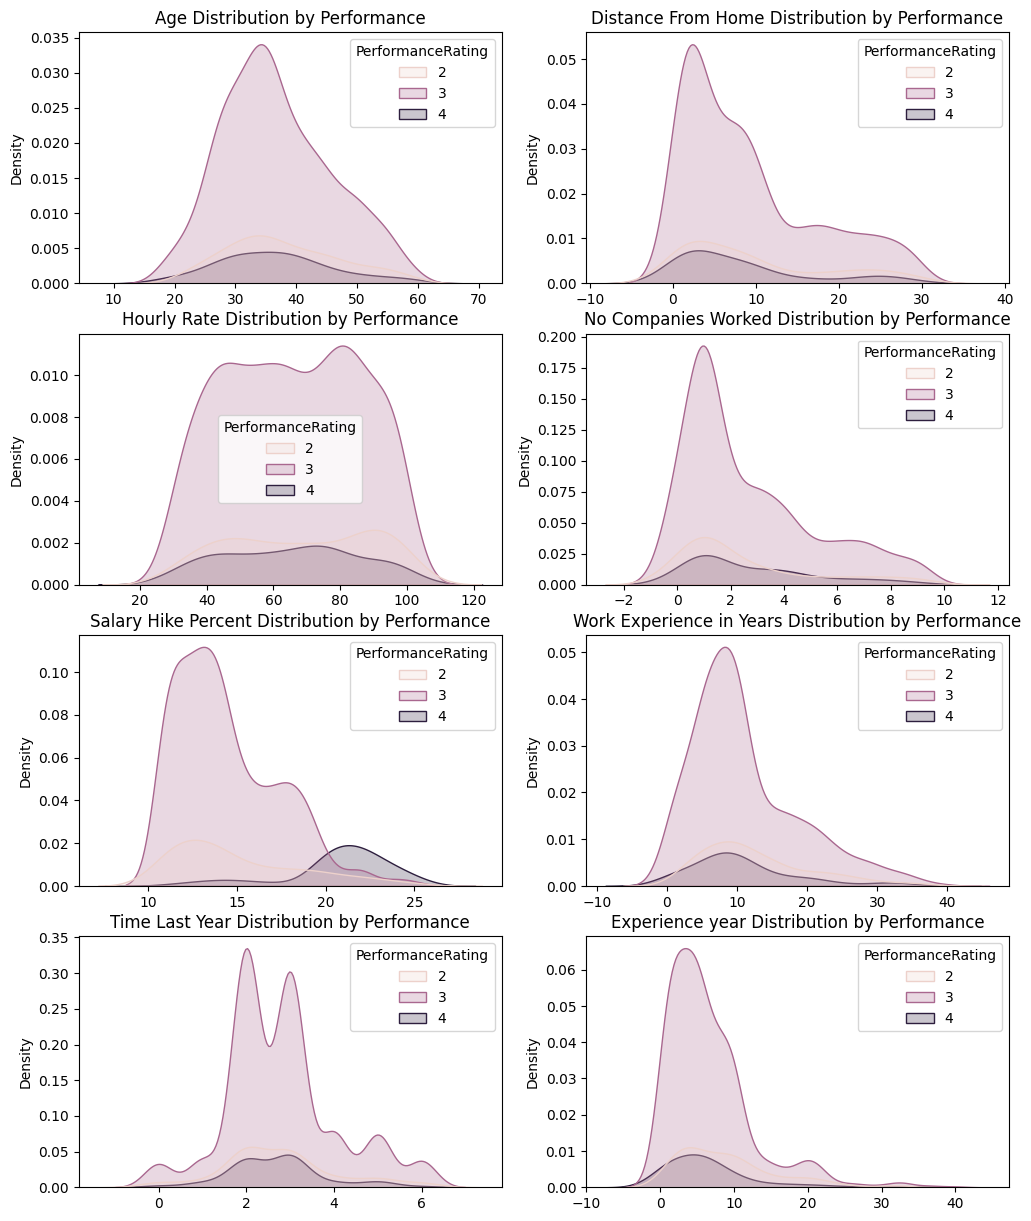

In [291]:
# Numerical features distribution by Performance Rating

fig,axes = plt.subplots(4,2,figsize=(12,15))

# Age distribution
sns.kdeplot(data=df, x='Age', hue='PerformanceRating', ax=axes[0,0], fill=True)
axes[0,0].set_title('Age Distribution by Performance')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Density')

# DistanceFromHome distribution
sns.kdeplot(data=df, x='DistanceFromHome', hue='PerformanceRating', ax=axes[0,1], fill=True)
axes[0,1].set_title('Distance From Home Distribution by Performance')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Density')

# EmpHourlyRate distribution
sns.kdeplot(data=df, x='EmpHourlyRate', hue='PerformanceRating', ax=axes[1,0], fill=True)
axes[1,0].set_title('Hourly Rate Distribution by Performance')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Density')


# NumCompaniesWorked distribution
sns.kdeplot(data=df, x='NumCompaniesWorked', hue='PerformanceRating', ax=axes[1,1], fill=True)
axes[1,1].set_title('No Companies Worked Distribution by Performance')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Density')

# EmpLastSalaryHikePercent distribution
sns.kdeplot(data=df, x='EmpLastSalaryHikePercent', hue='PerformanceRating', ax=axes[2,0], fill=True)
axes[2,0].set_title('Salary Hike Percent Distribution by Performance')
axes[2,0].set_xlabel('')
axes[2,0].set_ylabel('Density')

# TotalWorkExperienceInYears distribution
sns.kdeplot(data=df, x='TotalWorkExperienceInYears', hue='PerformanceRating', ax=axes[2,1], fill=True)
axes[2,1].set_title('Work Experience in Years Distribution by Performance')
axes[2,1].set_xlabel('')
axes[2,1].set_ylabel('Density')

# TrainingTimesLastYear distribution
sns.kdeplot(data=df, x='TrainingTimesLastYear', hue='PerformanceRating', ax=axes[3,0], fill=True)
axes[3,0].set_title('Time Last Year Distribution by Performance')
axes[3,0].set_xlabel('')
axes[3,0].set_ylabel('Density')

# ExperienceYearsAtThisCompany distribution
sns.kdeplot(data=df, x='ExperienceYearsAtThisCompany', hue='PerformanceRating', ax=axes[3,1], fill=True)
axes[3,1].set_title('Experience year Distribution by Performance')
axes[3,1].set_xlabel('')
axes[3,1].set_ylabel('Density')


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\4106095059.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PerformanceRating', y='Age', palette=custom_palette, ax=axes[0,0])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\4106095059.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PerformanceRating', y='DistanceFromHome', palette=custom_palette, ax=axes[0,1])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\4106095059.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=

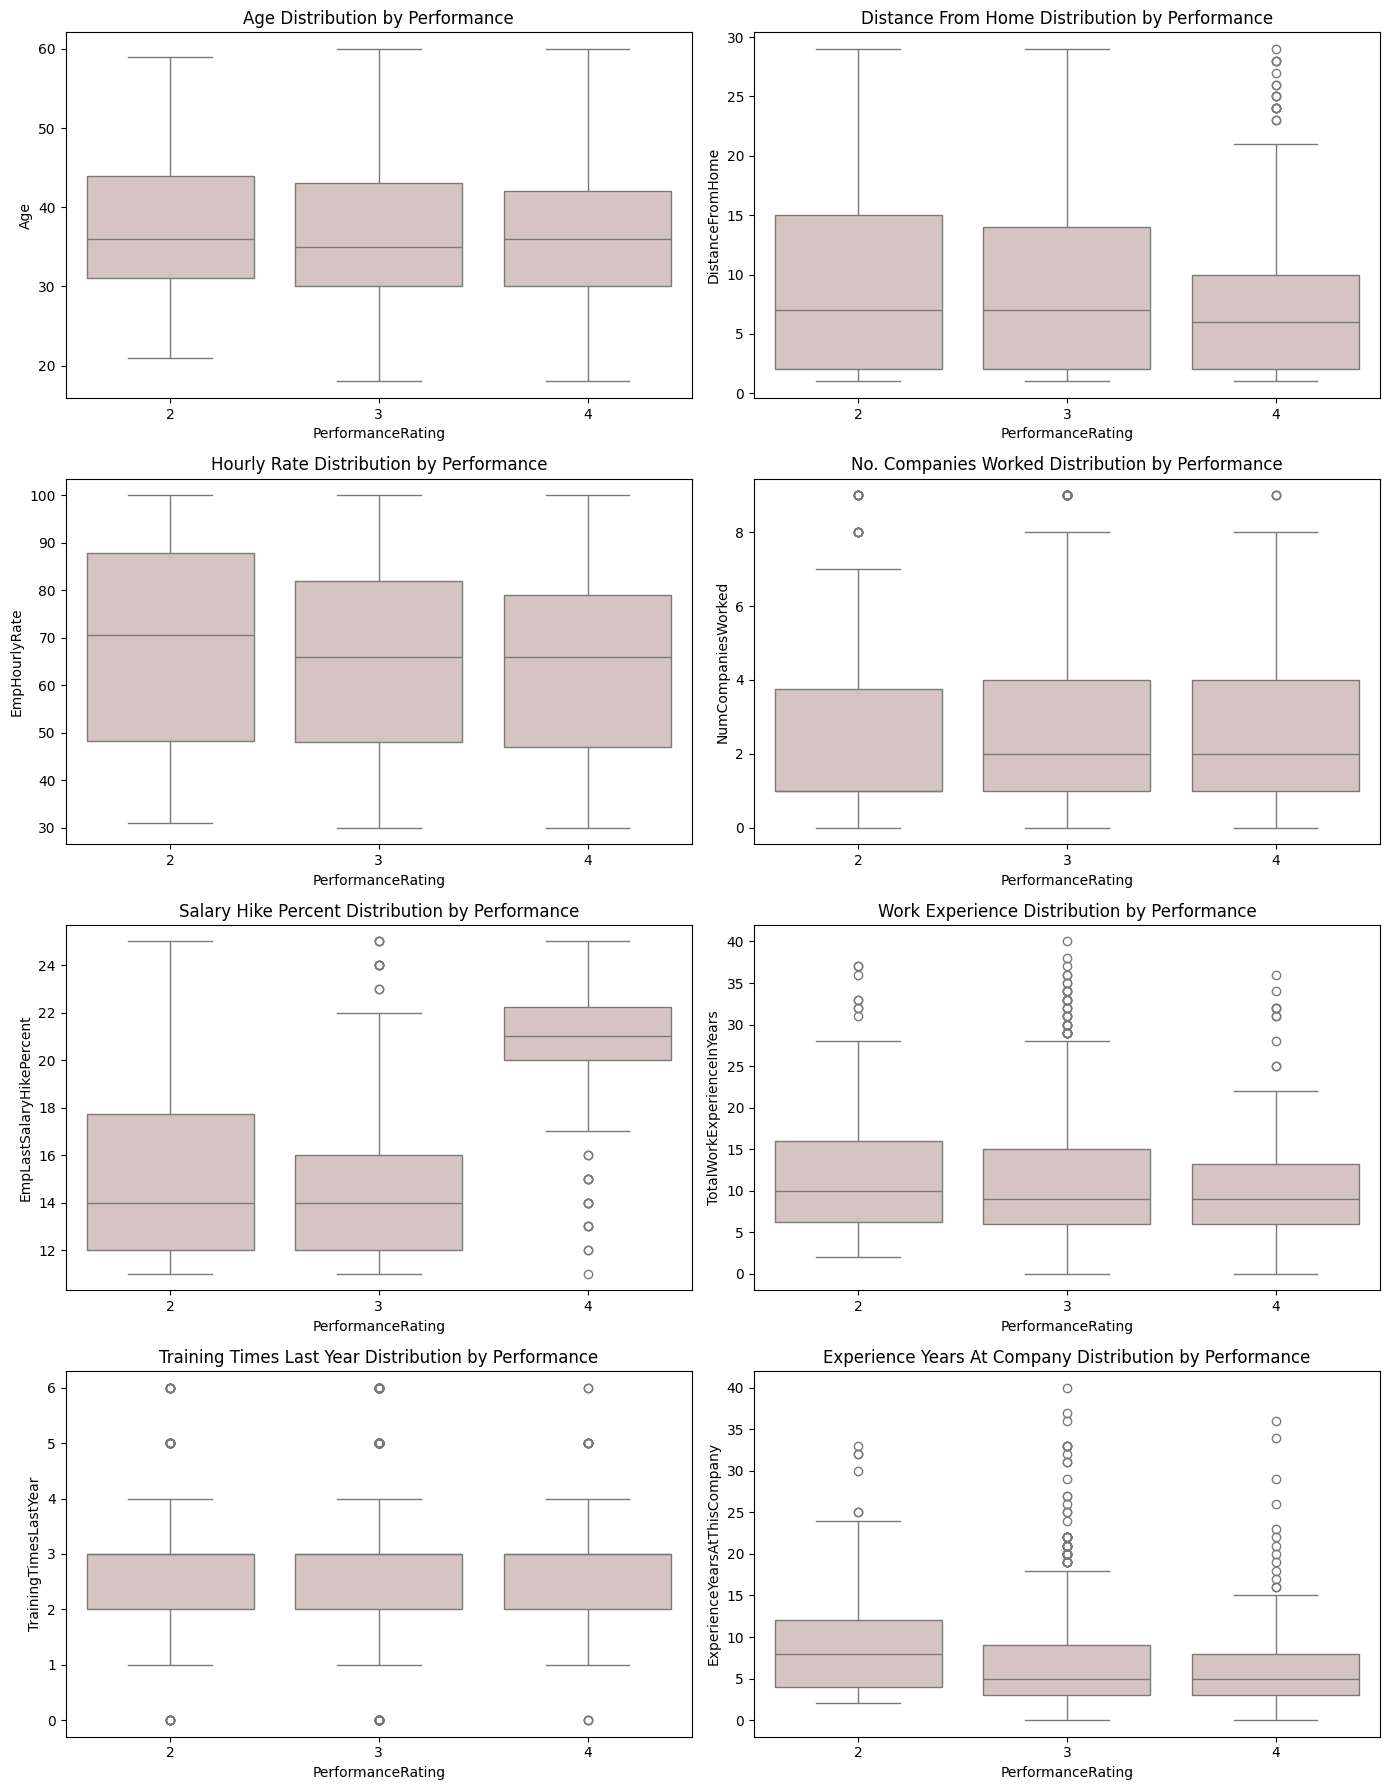

In [292]:
# Outlier distribution by Performance Rating

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
custom_palette = {"#D8C2BE"}

# Age distribution
sns.boxplot(data=df, x='PerformanceRating', y='Age', palette=custom_palette, ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Performance')

# DistanceFromHome distribution
sns.boxplot(data=df, x='PerformanceRating', y='DistanceFromHome', palette=custom_palette, ax=axes[0,1])
axes[0,1].set_title('Distance From Home Distribution by Performance')

# EmpHourlyRate distribution
sns.boxplot(data=df, x='PerformanceRating', y='EmpHourlyRate', palette=custom_palette, ax=axes[1,0])
axes[1,0].set_title('Hourly Rate Distribution by Performance')

# NumCompaniesWorked distribution
sns.boxplot(data=df, x='PerformanceRating', y='NumCompaniesWorked', palette=custom_palette, ax=axes[1,1])
axes[1,1].set_title('No. Companies Worked Distribution by Performance')

# EmpLastSalaryHikePercent distribution
sns.boxplot(data=df, x='PerformanceRating', y='EmpLastSalaryHikePercent', palette=custom_palette, ax=axes[2,0])
axes[2,0].set_title('Salary Hike Percent Distribution by Performance')

# TotalWorkExperienceInYears distribution
sns.boxplot(data=df, x='PerformanceRating', y='TotalWorkExperienceInYears', palette=custom_palette, ax=axes[2,1])
axes[2,1].set_title('Work Experience Distribution by Performance')

# TrainingTimesLastYear distribution
sns.boxplot(data=df, x='PerformanceRating', y='TrainingTimesLastYear', palette=custom_palette, ax=axes[3,0])
axes[3,0].set_title('Training Times Last Year Distribution by Performance')

# ExperienceYearsAtThisCompany distribution
sns.boxplot(data=df, x='PerformanceRating', y='ExperienceYearsAtThisCompany', palette=custom_palette, ax=axes[3,1])
axes[3,1].set_title('Experience Years At Company Distribution by Performance')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

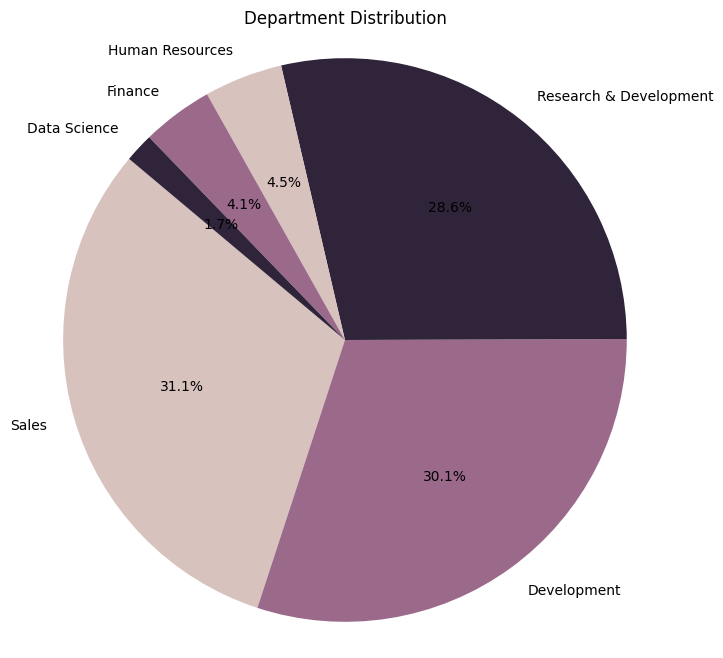

In [293]:
# pie chart for department distribution
custom_colors = ["#D8C2BE", "#9B6A8B", "#2F243A"]
department_counts = df["EmpDepartment"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(department_counts, labels=department_counts.index, autopct='%1.1f%%', startangle=140, colors=custom_colors)
plt.title("Department Distribution")
plt.axis('equal')
plt.show()

### Bivariate Analysis
Here we are going to discover the relationship between department and perfomance rating

In [294]:
# department wise distribution
department=df.groupby("EmpDepartment")["PerformanceRating"].sum()
department

EmpDepartment
Data Science                61
Development               1114
Finance                    136
Human Resources            158
Research & Development    1002
Sales                     1067
Name: PerformanceRating, dtype: int64

In [295]:
# cross tabulation for deparment perfomance
pd.crosstab(index=df["EmpDepartment"],columns=df["PerformanceRating"])

PerformanceRating,2,3,4
EmpDepartment,,,
Data Science,1,17,2
Development,13,304,44
Finance,15,30,4
Human Resources,10,38,6
Research & Development,68,234,41
Sales,87,251,35


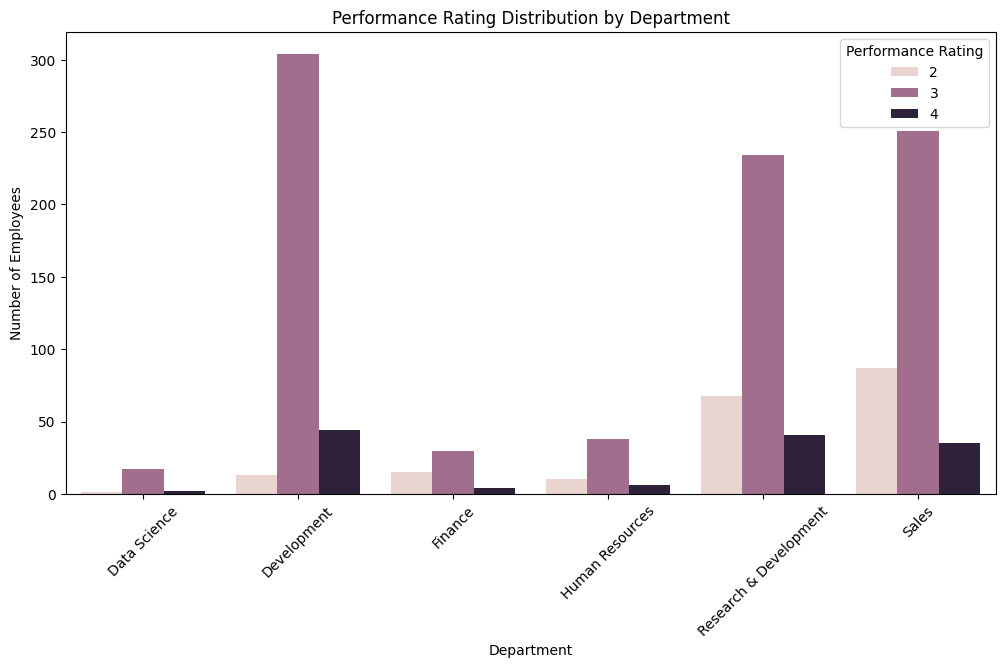

In [296]:
# Crosstab of Department vs Performance Rating
crosstab = pd.crosstab(index=df["EmpDepartment"], 
                       columns=df["PerformanceRating"])

# Reset index to make it tidy for seaborn
crosstab_reset = crosstab.reset_index()

# Melt into long format for grouped bar chart
crosstab_melted = crosstab_reset.melt(id_vars="EmpDepartment", 
                                      var_name="PerformanceRating", 
                                      value_name="Count")

# Plot grouped bar chart
plt.figure(figsize=(12,6))
sns.barplot(data=crosstab_melted, 
            x="EmpDepartment", 
            y="Count", 
            hue="PerformanceRating")
plt.title("Performance Rating Distribution by Department")
plt.ylabel("Number of Employees")
plt.xlabel("Department")
plt.legend(title="Performance Rating")
plt.xticks(rotation=45)
plt.show()


custom_palette = {
    2: "#D8C2BE",   # greenish shade
    3: "#9B6A8B",   # orange shade
    4: "#2F243A"

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\1060127664.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="PerformanceRating", data=df, palette=[color])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\1060127664.py:5: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x="PerformanceRating", data=df, palette=[color])


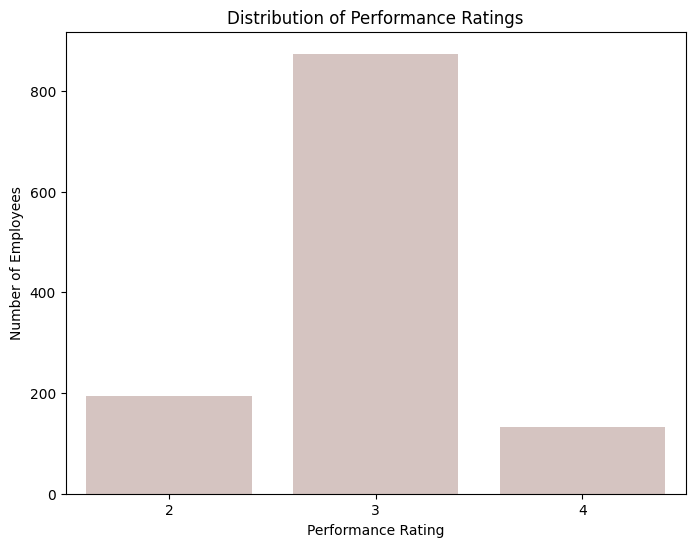

In [297]:
# Countplot for Performance Rating

plt.figure(figsize=(8,6))
color = "#D8C2BE"
sns.countplot(x="PerformanceRating", data=df, palette=[color])
plt.title("Distribution of Performance Ratings")
plt.xlabel("Performance Rating")
plt.ylabel("Number of Employees")
plt.show()


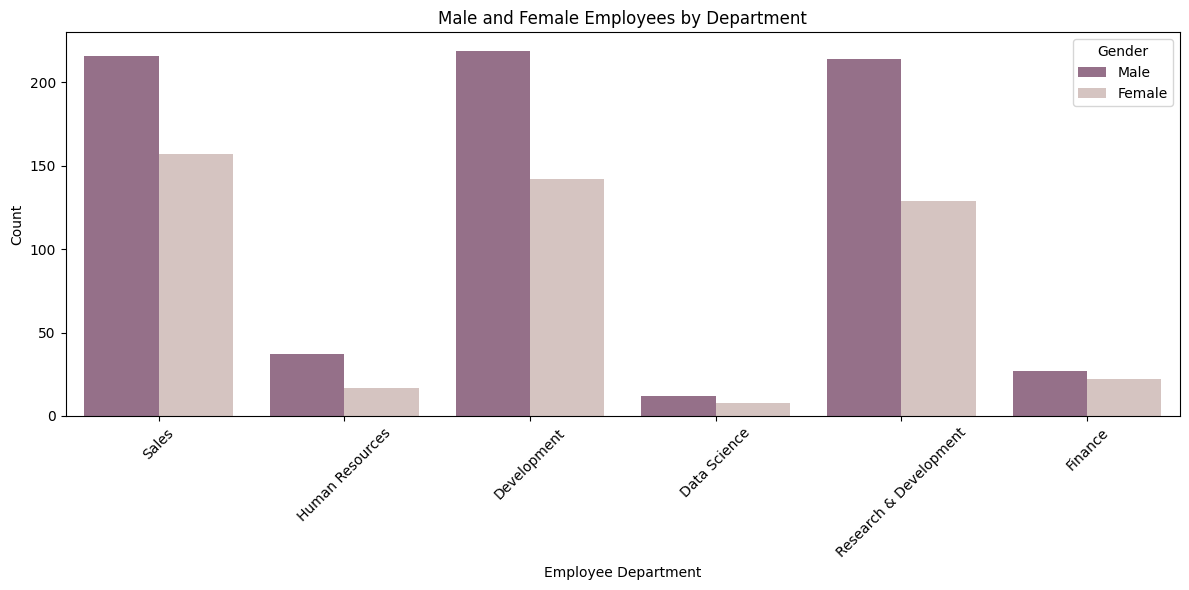

In [298]:
plt.figure(figsize=(12,6))

custom_colors = {
    'Male': "#9B6A8B",
    'Female': "#D8C2BE"
}

sns.countplot(
    x='EmpDepartment',
    hue='Gender',
    data=df,
    palette=custom_colors
)

plt.title('Male and Female Employees by Department')
plt.xlabel('Employee Department')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [299]:
# New dataframe for department and performance rating
departments = pd.get_dummies(df['EmpDepartment'])
performance = pd.DataFrame(df['PerformanceRating'])
emp_dept = pd.concat([departments,performance],axis=1)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\3600263181.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\3600263181.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\3600263181.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\3600263181.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

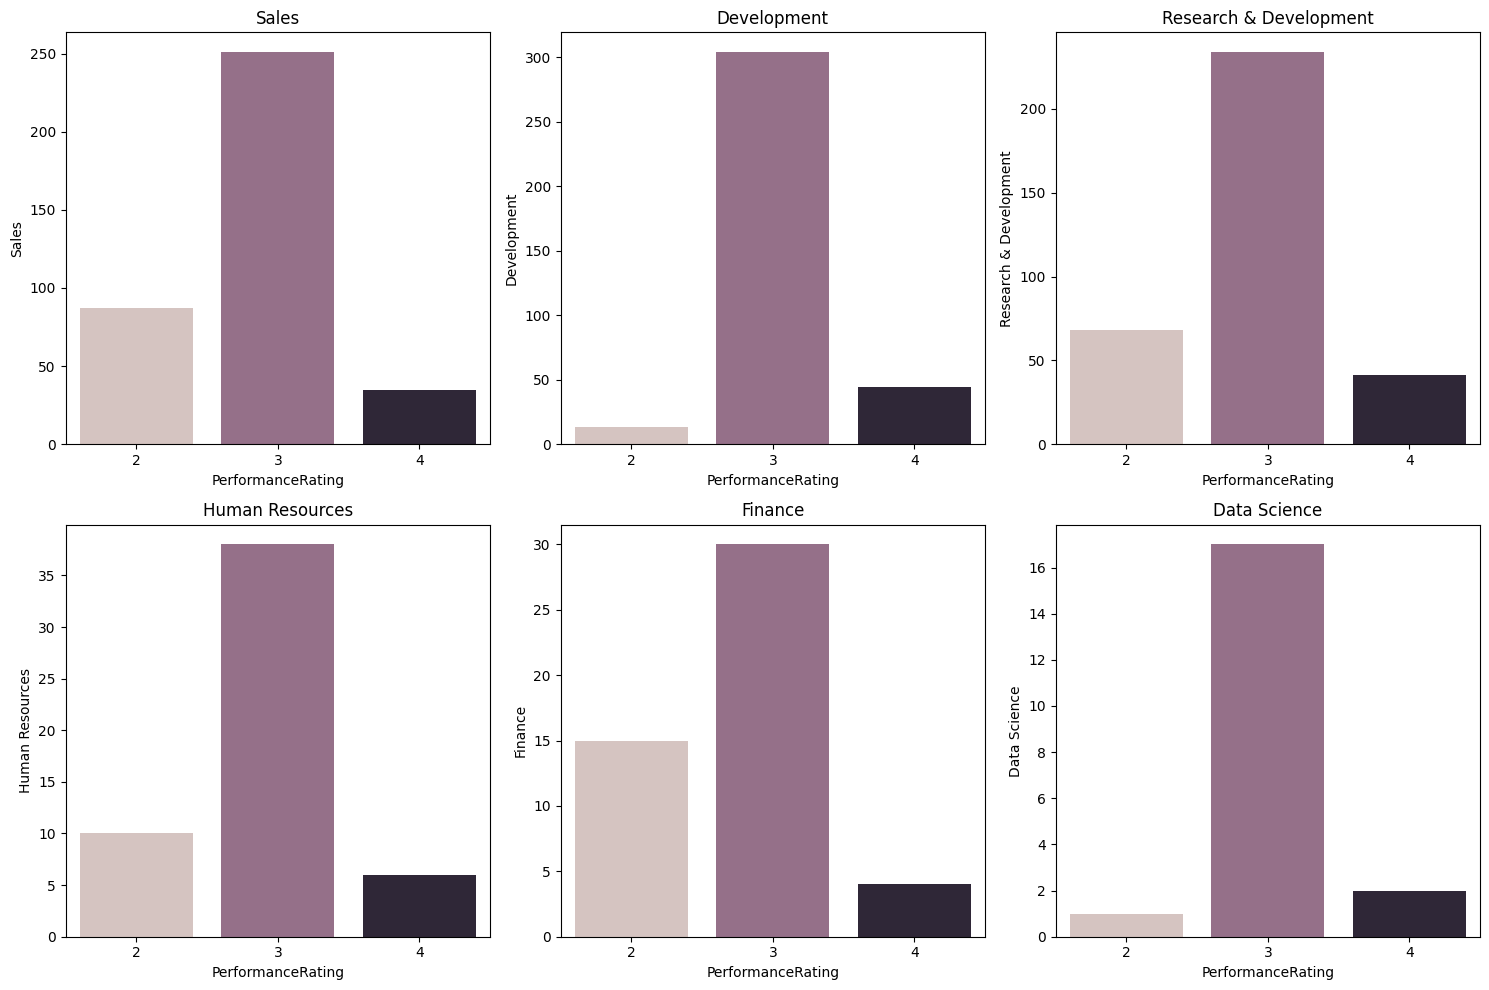

In [300]:
# Create Crosstab
emp_dept = pd.crosstab(
    df['PerformanceRating'],
    df['EmpDepartment']
)

# Reset index
emp_dept = emp_dept.reset_index()

# Custom Colors
custom_colors = ["#D8C2BE", "#9B6A8B", "#2F243A"]

# Figure
plt.figure(figsize=(15,10))

# Subplot 1
plt.subplot(2,3,1)
sns.barplot(
    x='PerformanceRating',
    y='Sales',
    data=emp_dept,
    palette=custom_colors
)
plt.title('Sales')

# Subplot 2
plt.subplot(2,3,2)
sns.barplot(
    x='PerformanceRating',
    y='Development',
    data=emp_dept,
    palette=custom_colors
)
plt.title('Development')

# Subplot 3
plt.subplot(2,3,3)
sns.barplot(
    x='PerformanceRating',
    y='Research & Development',
    data=emp_dept,
    palette=custom_colors
)
plt.title('Research & Development')

# Subplot 4
plt.subplot(2,3,4)
sns.barplot(
    x='PerformanceRating',
    y='Human Resources',
    data=emp_dept,
    palette=custom_colors
)
plt.title('Human Resources')

# Subplot 5
plt.subplot(2,3,5)
sns.barplot(
    x='PerformanceRating',
    y='Finance',
    data=emp_dept,
    palette=custom_colors
)
plt.title('Finance')

# Subplot 6
plt.subplot(2,3,6)
sns.barplot(
    x='PerformanceRating',
    y='Data Science',
    data=emp_dept,
    palette=custom_colors
)
plt.title('Data Science')

plt.tight_layout()
plt.show()

#### Multivariate analysis

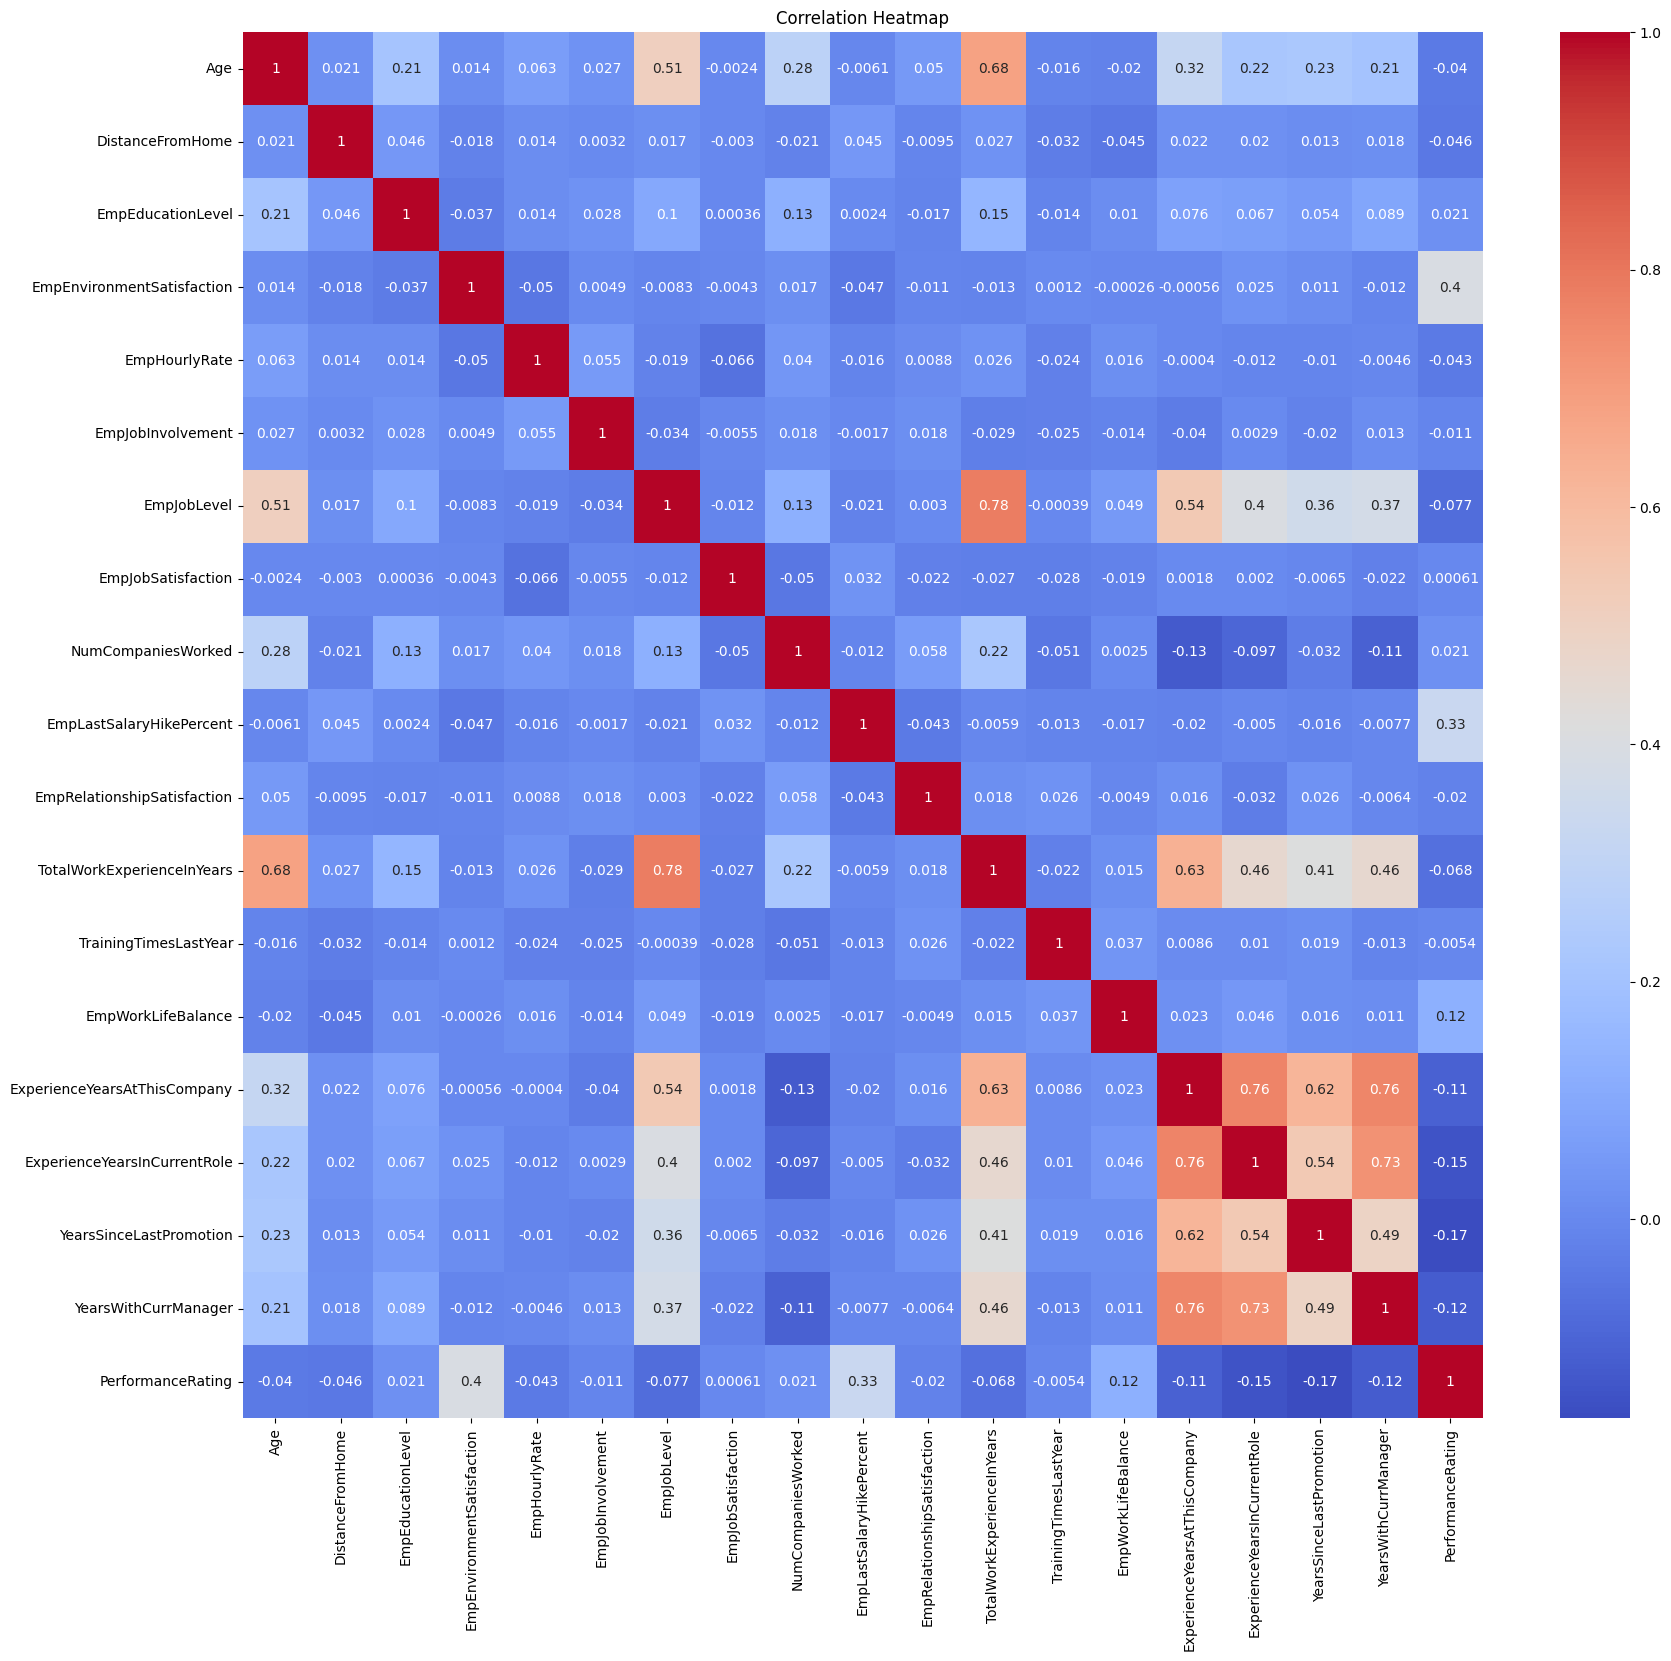

In [301]:
# drop emp number before drawing heatmap
df.drop(columns=['EmpNumber'], errors='ignore', inplace=True)

numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(20,18))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Statistical Analysis

use ANOVA and Chi square

In [302]:
# ANOVA for Numerical feature
numerical_features = [
    'Age',
    'DistanceFromHome',
    'EmpEducationLevel',
    'EmpEnvironmentSatisfaction',
    'EmpHourlyRate',
    'EmpJobInvolvement',
    'EmpJobLevel',
    'EmpJobSatisfaction',
    'NumCompaniesWorked',
    'EmpLastSalaryHikePercent',
    'EmpRelationshipSatisfaction',
    'TotalWorkExperienceInYears',
    'TrainingTimesLastYear',
    'EmpWorkLifeBalance',
    'ExperienceYearsAtThisCompany',
    'ExperienceYearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]
for feature in numerical_features:
    groups = [df[df['PerformanceRating'] == rating][feature] for rating in df['PerformanceRating'].unique()]
    f_stat, p_value = f_oneway(*groups)
    print(f"ANOVA for {feature}: F-statistic={f_stat:.2f}, p-value={p_value:.4f}")


ANOVA for Age: F-statistic=1.16, p-value=0.3151
ANOVA for DistanceFromHome: F-statistic=1.28, p-value=0.2787
ANOVA for EmpEducationLevel: F-statistic=0.42, p-value=0.6596
ANOVA for EmpEnvironmentSatisfaction: F-statistic=159.86, p-value=0.0000
ANOVA for EmpHourlyRate: F-statistic=1.44, p-value=0.2363
ANOVA for EmpJobInvolvement: F-statistic=0.61, p-value=0.5456
ANOVA for EmpJobLevel: F-statistic=5.32, p-value=0.0050
ANOVA for EmpJobSatisfaction: F-statistic=0.12, p-value=0.8852
ANOVA for NumCompaniesWorked: F-statistic=0.26, p-value=0.7682
ANOVA for EmpLastSalaryHikePercent: F-statistic=240.84, p-value=0.0000
ANOVA for EmpRelationshipSatisfaction: F-statistic=0.42, p-value=0.6564
ANOVA for TotalWorkExperienceInYears: F-statistic=3.89, p-value=0.0206
ANOVA for TrainingTimesLastYear: F-statistic=0.35, p-value=0.7013
ANOVA for EmpWorkLifeBalance: F-statistic=11.06, p-value=0.0000
ANOVA for ExperienceYearsAtThisCompany: F-statistic=12.38, p-value=0.0000
ANOVA for ExperienceYearsInCurrentRo

In [303]:
# chi square for categorical features
categorical_features = [
    'Gender',
    'EducationBackground',
    'MaritalStatus',
    'EmpDepartment',
    'EmpJobRole',
    'BusinessTravelFrequency',
    'OverTime',
    'Attrition']
chi2_result = {}
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['PerformanceRating'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    chi2_result[feature] = (chi2, p)
print(f"Chi-Square Test result for categorical feature")
for feature,result in chi2_result.items():
    print(f"{feature}: Chi2={result[0]:.2f}, p-value={result[1]:.4f}")



Chi-Square Test result for categorical feature
Gender: Chi2=0.16, p-value=0.9218
EducationBackground: Chi2=10.22, p-value=0.4216
MaritalStatus: Chi2=6.13, p-value=0.1894
EmpDepartment: Chi2=70.33, p-value=0.0000
EmpJobRole: Chi2=97.74, p-value=0.0000
BusinessTravelFrequency: Chi2=4.40, p-value=0.3549
OverTime: Chi2=11.28, p-value=0.0035
Attrition: Chi2=2.57, p-value=0.2771


### Data Preprocessing


In [304]:
# Outlier Datection by using IQR method for numerical features
def detect_outliers_iqr(df, features):
    df_clean = df.copy()
    # Use for loop to iterate through each unique value in the PerformanceRating column
    for ft in features:
        Q1 = df_clean[ft].quantile(0.25)
        Q3 = df_clean[ft].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df_clean[(df_clean[ft] < lower_bound) | (df_clean[ft] > upper_bound)]
    return df_clean, outliers

In [305]:
# define columns to check for outliers
features = ['EmpEnvironmentSatisfaction','EmpLastSalaryHikePercent','ExperienceYearsInCurrentRole', 'ExperienceYearsAtThisCompany','YearsSinceLastPromotion', 'YearsWithCurrManager']
df_clean = detect_outliers_iqr(df, features)

In [306]:
# print verify outliers have been removed
print(f"Before outlier removal: {df.shape[0]} rows")
print(f"After outlier removal: {df_clean[0].shape[0]} rows")

Before outlier removal: 1200 rows
After outlier removal: 1200 rows


In [307]:
# print new dataset after outlier removal
df_clean[0].head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,...,4,10,2,2,10,7,0,8,No,3
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,...,4,20,2,3,7,7,1,7,No,3
2,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,...,3,20,2,3,18,13,1,12,No,4
3,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,...,2,23,2,2,21,6,12,6,No,3
4,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,...,4,10,1,3,2,2,2,2,No,3


In [308]:
# Encoding categorical variables
encoder = LabelEncoder()
#Data.EmpNumber = encoder.fit_transform(Data.EmpNumber)
df_clean[0].Gender  = encoder.fit_transform(df_clean[0].Gender)
df_clean[0].EducationBackground  = encoder.fit_transform(df_clean[0].EducationBackground )
df_clean[0].MaritalStatus = encoder.fit_transform(df_clean[0].MaritalStatus)
df_clean[0].EmpDepartment = encoder.fit_transform(df_clean[0].EmpDepartment)
df_clean[0].EmpJobRole = encoder.fit_transform(df_clean[0].EmpJobRole)
df_clean[0].BusinessTravelFrequency = encoder.fit_transform(df_clean[0].BusinessTravelFrequency)
df_clean[0].OverTime  = encoder.fit_transform(df_clean[0].OverTime )
df_clean[0].Attrition  = encoder.fit_transform(df_clean[0].Attrition )

### Splitting data
select best important features

In [309]:
features = ['EmpDepartment','EmpJobRole','EmpEnvironmentSatisfaction','EmpLastSalaryHikePercent','ExperienceYearsInCurrentRole', 'ExperienceYearsAtThisCompany','YearsSinceLastPromotion', 'YearsWithCurrManager']
X = df_clean[0][features]
y = df_clean[0]['PerformanceRating']

In [310]:
# print first 5 rows of features
X.head()

,EmpDepartment,EmpJobRole,EmpEnvironmentSatisfaction,EmpLastSalaryHikePercent,ExperienceYearsInCurrentRole,ExperienceYearsAtThisCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,5,13,4,12,7,10,0,8
1,5,13,4,12,7,7,1,7
2,5,13,4,21,13,18,1,12
3,3,8,2,15,6,21,12,6
4,5,13,1,14,2,2,2,2


In [311]:
# print unique values of target variable
y.unique()

array([3, 4, 2])

### Train and Test

In [312]:
# splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [313]:
X_train.shape

(960, 8)

In [314]:
X_test.shape

(240, 8)

In [315]:
# before SMOTE
print("Before SMOTE:")
print(Counter(y_train))

Before SMOTE:
Counter({3: 690, 2: 165, 4: 105})


In [316]:
# Class Imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [317]:
print("\nAfter SMOTE:")
print(Counter(y_train_res))


After SMOTE:
Counter({2: 690, 3: 690, 4: 690})


### Model Selectiom

#### Random Forest

In [318]:
# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [319]:
# prediction
y_pred = rf.predict(X_test)


In [320]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.9083333333333333
Classification Report:
              precision    recall  f1-score   support

           2       0.81      0.90      0.85        29
           3       0.95      0.95      0.95       184
           4       0.75      0.67      0.71        27

    accuracy                           0.91       240
   macro avg       0.84      0.84      0.83       240
weighted avg       0.91      0.91      0.91       240

Confusion Matrix:
[[ 26   2   1]
 [  5 174   5]
 [  1   8  18]]


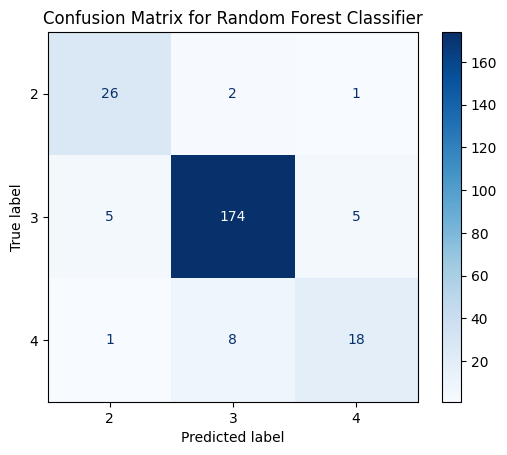

In [321]:
# confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

#### Support Vector

In [322]:
# Support vector
SVC = SVC(random_state=42, kernel='rbf', C=1.0, gamma='scale')
SVC.fit(X_train_res, y_train_res)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [323]:
# prediction
y_pred_svc = SVC.predict(X_test)


In [324]:
# Model Evaluation for SVC
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Classification Report:")
print(classification_report(y_test, y_pred_svc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc))

Accuracy: 0.7375
Classification Report:
              precision    recall  f1-score   support

           2       0.39      0.69      0.50        29
           3       0.94      0.74      0.83       184
           4       0.47      0.78      0.58        27

    accuracy                           0.74       240
   macro avg       0.60      0.74      0.64       240
weighted avg       0.82      0.74      0.76       240

Confusion Matrix:
[[ 20   4   5]
 [ 29 136  19]
 [  2   4  21]]


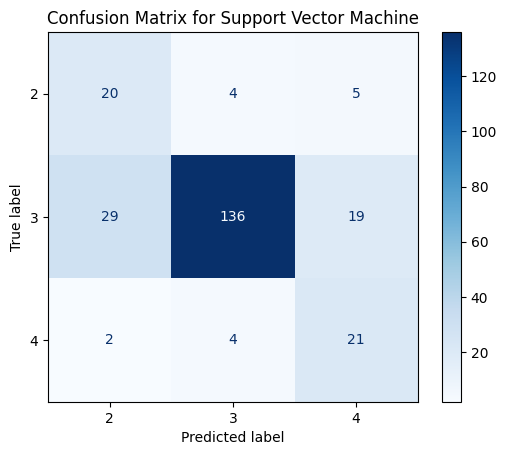

In [325]:
# confusion matrix visualization
cm = confusion_matrix(y_test, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Support Vector Machine")
plt.show()

#### K Nearest Neighbors

In [326]:
# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_res, y_train_res)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [327]:
# prediction
y_pred_knn = knn.predict(X_test)

In [328]:
# knn Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.7333333333333333
Classification Report:
              precision    recall  f1-score   support

           2       0.35      0.62      0.44        29
           3       0.92      0.76      0.83       184
           4       0.50      0.67      0.57        27

    accuracy                           0.73       240
   macro avg       0.59      0.68      0.62       240
weighted avg       0.80      0.73      0.76       240

Confusion Matrix:
[[ 18   5   6]
 [ 32 140  12]
 [  2   7  18]]


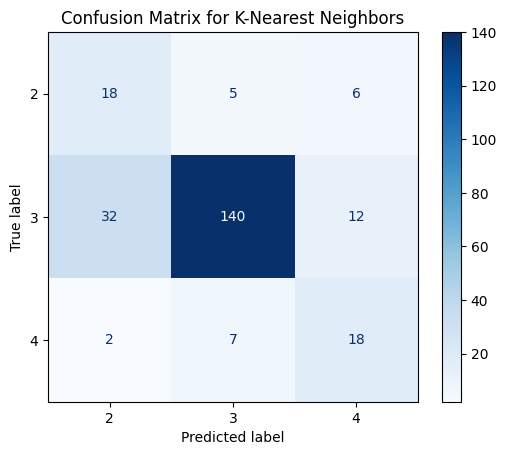

In [329]:
# confusion matrix visualization for knn
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for K-Nearest Neighbors")
plt.show()

#### Decision Tree

In [330]:
# Decision Tree
Dec_model = DecisionTreeClassifier(random_state=42)
Dec_model.fit(X_train_res, y_train_res)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [331]:
# prediction
y_pred_dec = Dec_model.predict(X_test)

In [332]:
# Decision Tree Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dec))
print("Classification Report:")
print(classification_report(y_test, y_pred_dec))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dec))

Accuracy: 0.8791666666666667
Classification Report:
              precision    recall  f1-score   support

           2       0.76      0.86      0.81        29
           3       0.94      0.91      0.92       184
           4       0.66      0.70      0.68        27

    accuracy                           0.88       240
   macro avg       0.78      0.82      0.80       240
weighted avg       0.88      0.88      0.88       240

Confusion Matrix:
[[ 25   4   0]
 [  7 167  10]
 [  1   7  19]]


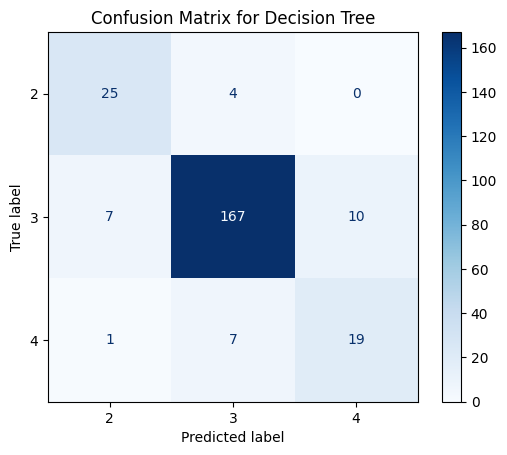

In [333]:
# confusion matrix visualization for Decision Tree
cm = confusion_matrix(y_test, y_pred_dec)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Decision Tree")
plt.show()

In [334]:
# Summarize result for all model (Model and Accuracy)
models = ['Random Forest', 'Support Vector Machine', 'K-Nearest Neighbors', 'Decision Tree']
accuracies = [0.91, 0.74, 0.73, 0.87]
results_df = pd.DataFrame({'Model': models, 'Accuracy': accuracies})
print(results_df)

                    Model  Accuracy
0           Random Forest      0.91
1  Support Vector Machine      0.74
2     K-Nearest Neighbors      0.73
3           Decision Tree      0.87


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13584\2141780089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")


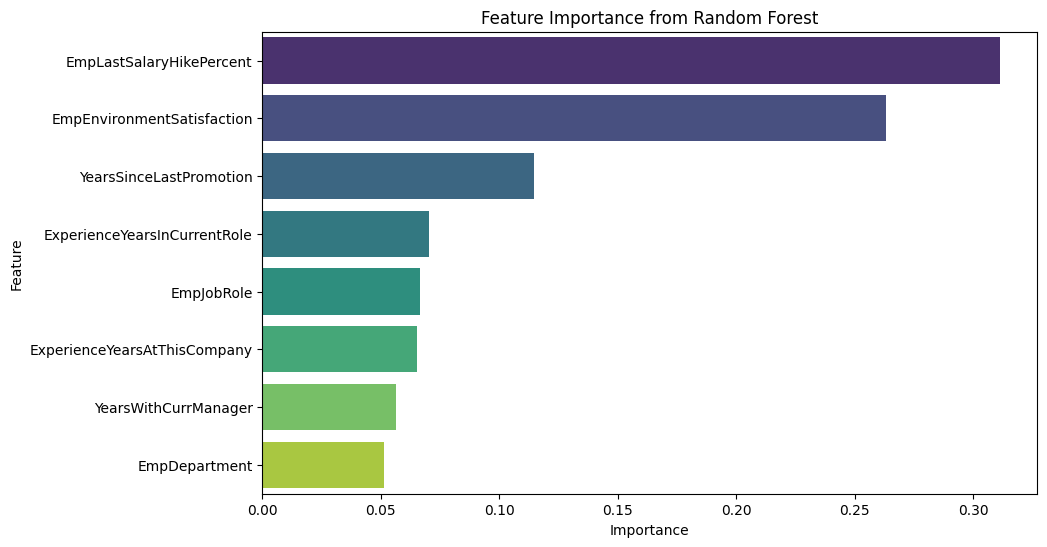

In [335]:
# feature importance for Random Forest
feature_importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [336]:
# Prediction equation test for Random Forest
# Get the feature values for a sample employee
sample_employee = X_test.iloc[0]
print("Sample Employee Features:")
print(sample_employee)
# Predict the performance rating for the sample employee
predicted_rating = rf.predict([sample_employee])
print(f"Predicted Performance Rating for the sample employee: {predicted_rating[0]}")


Sample Employee Features:
EmpDepartment                    1
EmpJobRole                       3
EmpEnvironmentSatisfaction       1
EmpLastSalaryHikePercent        20
ExperienceYearsInCurrentRole     2
ExperienceYearsAtThisCompany     2
YearsSinceLastPromotion          2
YearsWithCurrManager             2
Name: 1178, dtype: int64
Predicted Performance Rating for the sample employee: 3


C:\Users\Administrator\AppData\Roaming\uv\python\cpython-3.14-windows-x86_64-none\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [337]:
# Saving Model
joblib.dump(rf, 'employee_performance_rf_model.pkl')
print("Model saved successfully.")

Model saved successfully.
